In [1]:
# ═══ CELL 1 — ALL IMPORTS (run this first) ═══════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pickle, os, warnings, time
warnings.filterwarnings('ignore')

from sklearn.model_selection    import train_test_split
from sklearn.preprocessing      import StandardScaler
from sklearn.ensemble           import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    roc_curve, precision_recall_curve,
    average_precision_score, f1_score,
    recall_score, precision_score
)

# ── Paths (Windows-safe) ──────────────────────────────────────────
BASE_DIR  = os.path.normpath(os.path.join(os.getcwd(), '..'))
DATA_PATH = os.path.join(BASE_DIR, 'data',   'loans.csv')
MODEL_DIR = os.path.join(BASE_DIR, 'models')
PLOTS_DIR = os.path.join(BASE_DIR, 'plots')
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

# ── Plot style ────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
C = {'paid':   '#27ae60',
     'default':'#e74c3c',
     'blue':   '#2980b9',
     'orange': '#e67e22'}

print(f'DATA  → {DATA_PATH}')
print(f'MODEL → {MODEL_DIR}')
print(f'PLOTS → {PLOTS_DIR}')
print('All imports OK ✅')

DATA  → d:\MS AI Feb 2026\DL\Loan-Predictor\data\loans.csv
MODEL → d:\MS AI Feb 2026\DL\Loan-Predictor\models
PLOTS → d:\MS AI Feb 2026\DL\Loan-Predictor\plots
All imports OK ✅


In [2]:
# ═══ CELL 2 — LOAD & FILTER RESOLVED LOANS ═══════════════════════
print('Loading CSV … (584 MB, ~30 seconds)')
t0  = time.time()
raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Loaded {len(raw):,} rows × {raw.shape[1]} cols '
      f'in {time.time()-t0:.0f}s')

# Keep only loans with a definitive outcome
PAID_VALS    = ['Fully Paid']
DEFAULT_VALS = ['Charged Off', 'Default', 'Late (31-120 days)']

df = raw[raw['loan_status'].isin(PAID_VALS + DEFAULT_VALS)].copy()
df['Default'] = df['loan_status'].isin(DEFAULT_VALS).astype(np.int8)

print(f'\nResolved loans : {len(df):,}')
print(f'Default rate   : {df["Default"].mean():.2%}')
print(df['loan_status'].value_counts())

Loading CSV … (584 MB, ~30 seconds)
Loaded 1,048,575 rows × 150 cols in 54s

Resolved loans : 622,682
Default rate   : 22.50%
loan_status
Fully Paid            482595
Charged Off           129187
Late (31-120 days)     10879
Default                   21
Name: count, dtype: int64


In [3]:
# ═══ CELL 3 — FEATURE SELECTION & TYPE FIXING ════════════════════
WANT = ['loan_amnt', 'int_rate', 'installment', 'annual_inc',
        'dti', 'fico_range_low', 'fico_range_high',
        'open_acc', 'revol_util', 'total_acc',
        'emp_length', 'term',
        'home_ownership', 'purpose', 'grade',
        'Default']

# Only keep columns present in this CSV
WANT = [c for c in WANT if c in df.columns]
df   = df[WANT].copy()

# ── Fix % strings ─────────────────────────────────────────────────
for col in ['int_rate', 'revol_util']:
    if col in df.columns and df[col].dtype == object:
        df[col] = df[col].str.replace('%', '', regex=False).astype(float)

# ── Fix term "36 months" → 36 ─────────────────────────────────────
if df['term'].dtype == object:
    df['term'] = df['term'].str.extract(r'(\d+)').astype(int)

# ── Fix emp_length ────────────────────────────────────────────────
EMP = {'< 1 year': 0, '1 year': 1,  '2 years': 2,
       '3 years':  3, '4 years': 4,  '5 years': 5,
       '6 years':  6, '7 years': 7,  '8 years': 8,
       '9 years':  9, '10+ years': 10}
if 'emp_length' in df.columns:
    df['emp_length'] = df['emp_length'].map(EMP)

# ── Average FICO ──────────────────────────────────────────────────
if {'fico_range_low', 'fico_range_high'}.issubset(df.columns):
    df['credit_score'] = (
        df['fico_range_low'] + df['fico_range_high']
    ) / 2
    df.drop(columns=['fico_range_low', 'fico_range_high'], inplace=True)

# ── Fill NaN — numeric with median, categorical with mode ─────────
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print(f'Shape after cleaning : {df.shape}')
print(f'NaN remaining        : {df.isnull().sum().sum()}')
print(f'\nDtypes:\n{df.dtypes.value_counts()}')

Shape after cleaning : (622682, 15)
NaN remaining        : 40062

Dtypes:
float64    10
str         4
int8        1
Name: count, dtype: int64


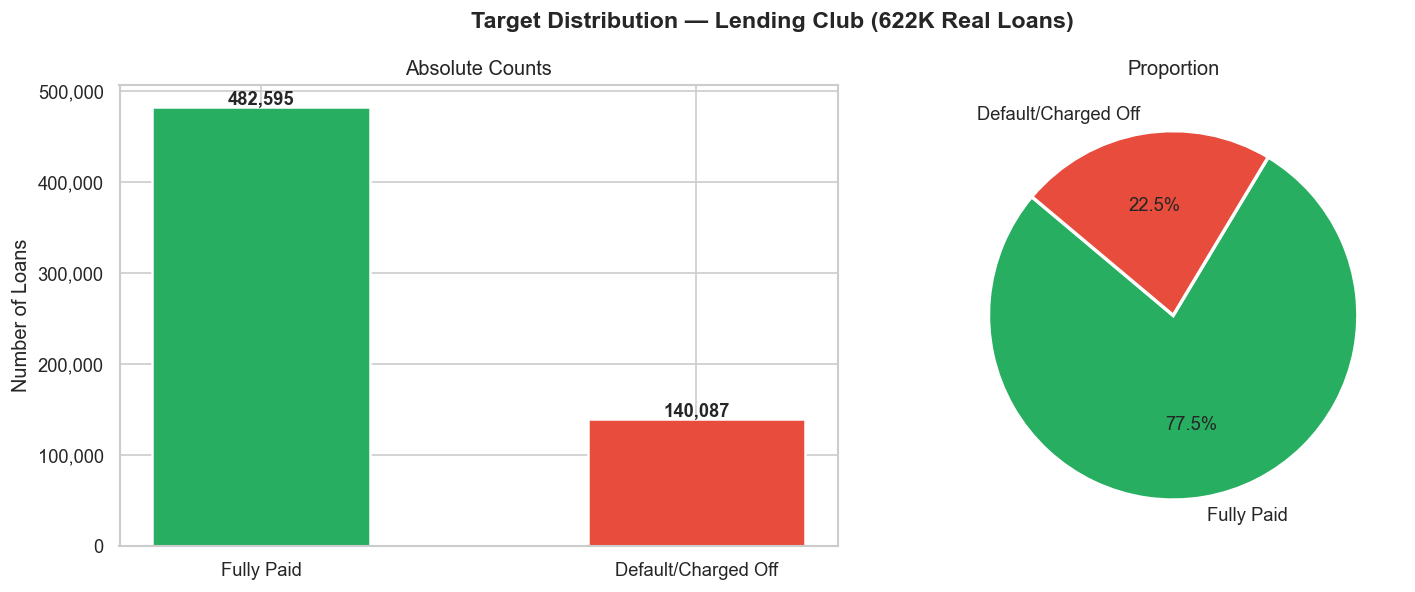

✅ target_distribution.png


In [4]:
# ═══ CELL 4 — PLOT: Target Distribution ══════════════════════════
counts = df['Default'].value_counts().sort_index()
labels = ['Fully Paid', 'Default/Charged Off']
colors = [C['paid'], C['default']]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Target Distribution — Lending Club (622K Real Loans)',
             fontsize=14, fontweight='bold')

bars = axes[0].bar(labels, counts.values, color=colors,
                   edgecolor='white', linewidth=1.5, width=0.5)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].set_ylabel('Number of Loans')
axes[0].set_title('Absolute Counts')
for b, v in zip(bars, counts.values):
    axes[0].text(b.get_x() + b.get_width()/2,
                 b.get_height() + 2000,
                 f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proportion')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'target_distribution.png'),
            bbox_inches='tight')
plt.show()
print('✅ target_distribution.png')

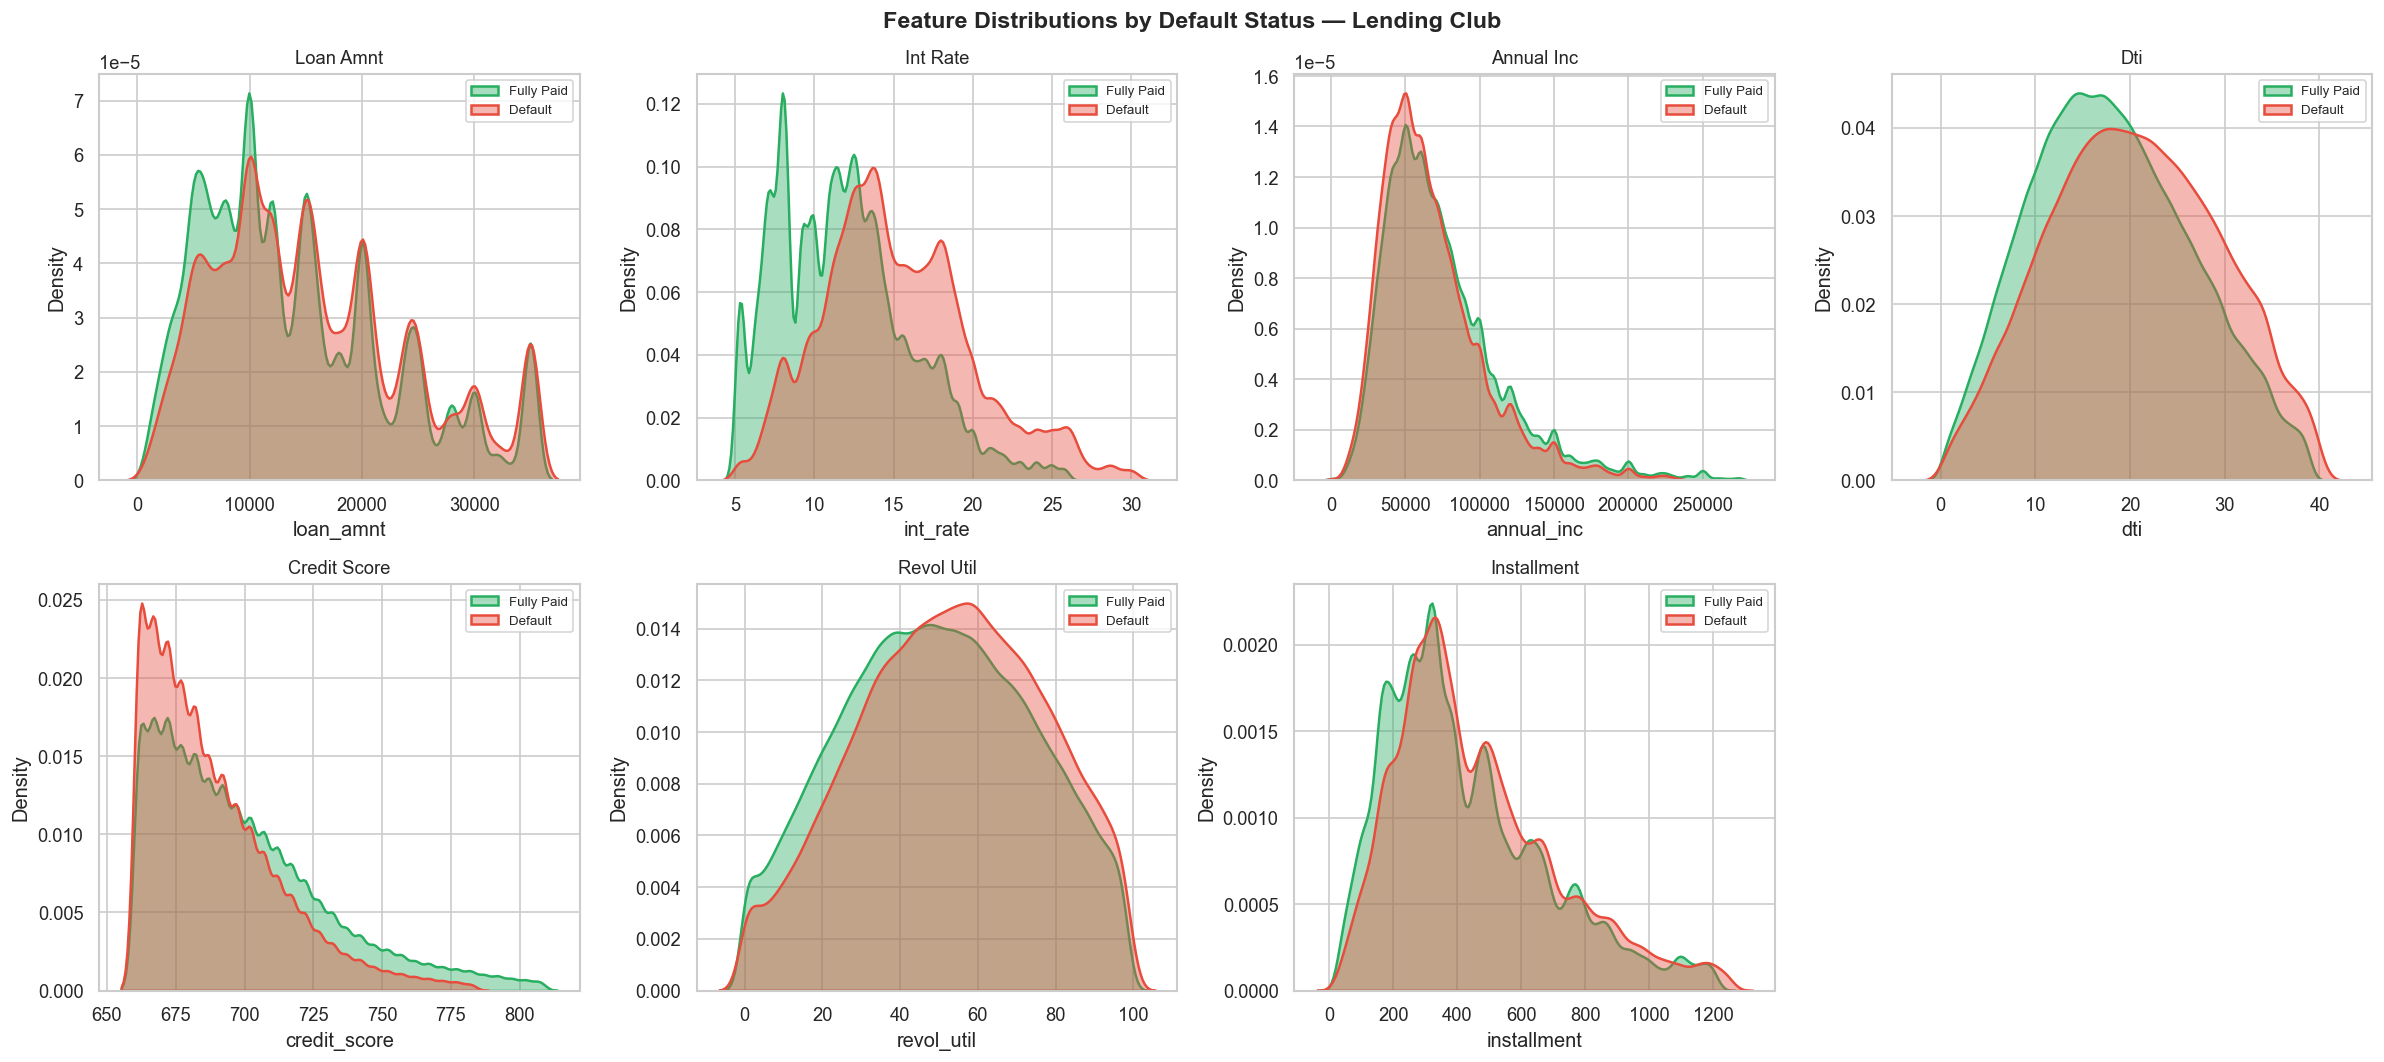

✅ feature_distributions.png


In [5]:
# ═══ CELL 5 — PLOT: Numeric Feature Distributions ════════════════
NUM_COLS = [c for c in ['loan_amnt', 'int_rate', 'annual_inc',
                         'dti', 'credit_score', 'revol_util',
                         'installment']
            if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
fig.suptitle(
    'Feature Distributions by Default Status — Lending Club',
    fontsize=14, fontweight='bold')

for i, col in enumerate(NUM_COLS):
    ax = axes[i]
    for label, color, name in zip(
        [0, 1],
        [C['paid'], C['default']],
        ['Fully Paid', 'Default']
    ):
        vals = df[df['Default'] == label][col].dropna()
        vals = vals[vals <= vals.quantile(0.99)]
        sns.kdeplot(vals, ax=ax, color=color, fill=True,
                    alpha=0.40, label=name, linewidth=1.5)
    ax.set_title(col.replace('_', ' ').title(), fontsize=11)
    ax.legend(fontsize=8)

for j in range(len(NUM_COLS), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'feature_distributions.png'),
            bbox_inches='tight')
plt.show()
print('✅ feature_distributions.png')

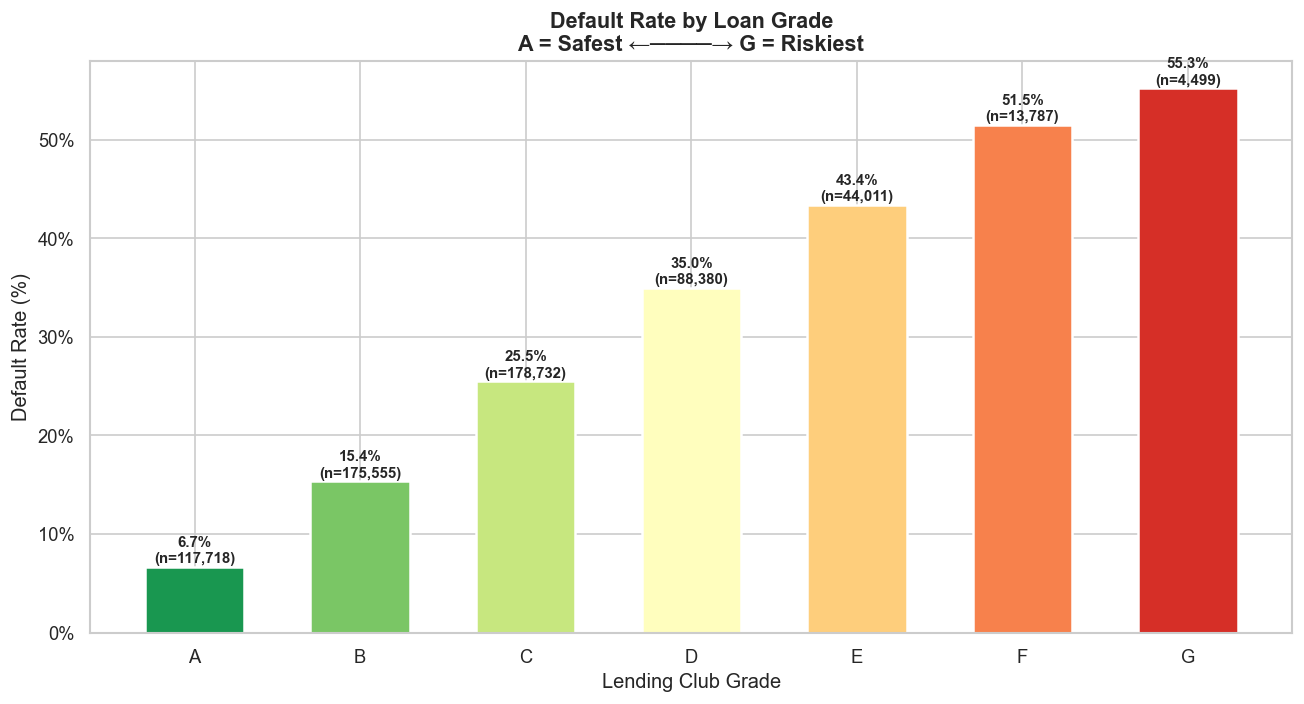

✅ default_rate_by_grade.png


In [6]:
# ═══ CELL 6 — PLOT: Default Rate by Grade ════════════════════════
gdf = (df.groupby('grade')['Default']
         .agg(['mean', 'count'])
         .reset_index()
         .rename(columns={'mean': 'rate', 'count': 'n'})
         .sort_values('grade'))

fig, ax = plt.subplots(figsize=(11, 6))
bar_c = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(gdf)))
bars  = ax.bar(gdf['grade'], gdf['rate'] * 100,
               color=bar_c, edgecolor='white',
               linewidth=1.5, width=0.6)
for b, rate, n in zip(bars, gdf['rate'], gdf['n']):
    ax.text(b.get_x() + b.get_width()/2,
            b.get_height() + 0.4,
            f'{rate*100:.1f}%\n(n={n:,})',
            ha='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Lending Club Grade', fontsize=12)
ax.set_ylabel('Default Rate (%)',   fontsize=12)
ax.set_title(
    'Default Rate by Loan Grade\nA = Safest ←────→ G = Riskiest',
    fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'default_rate_by_grade.png'),
            bbox_inches='tight')
plt.show()
print('✅ default_rate_by_grade.png')

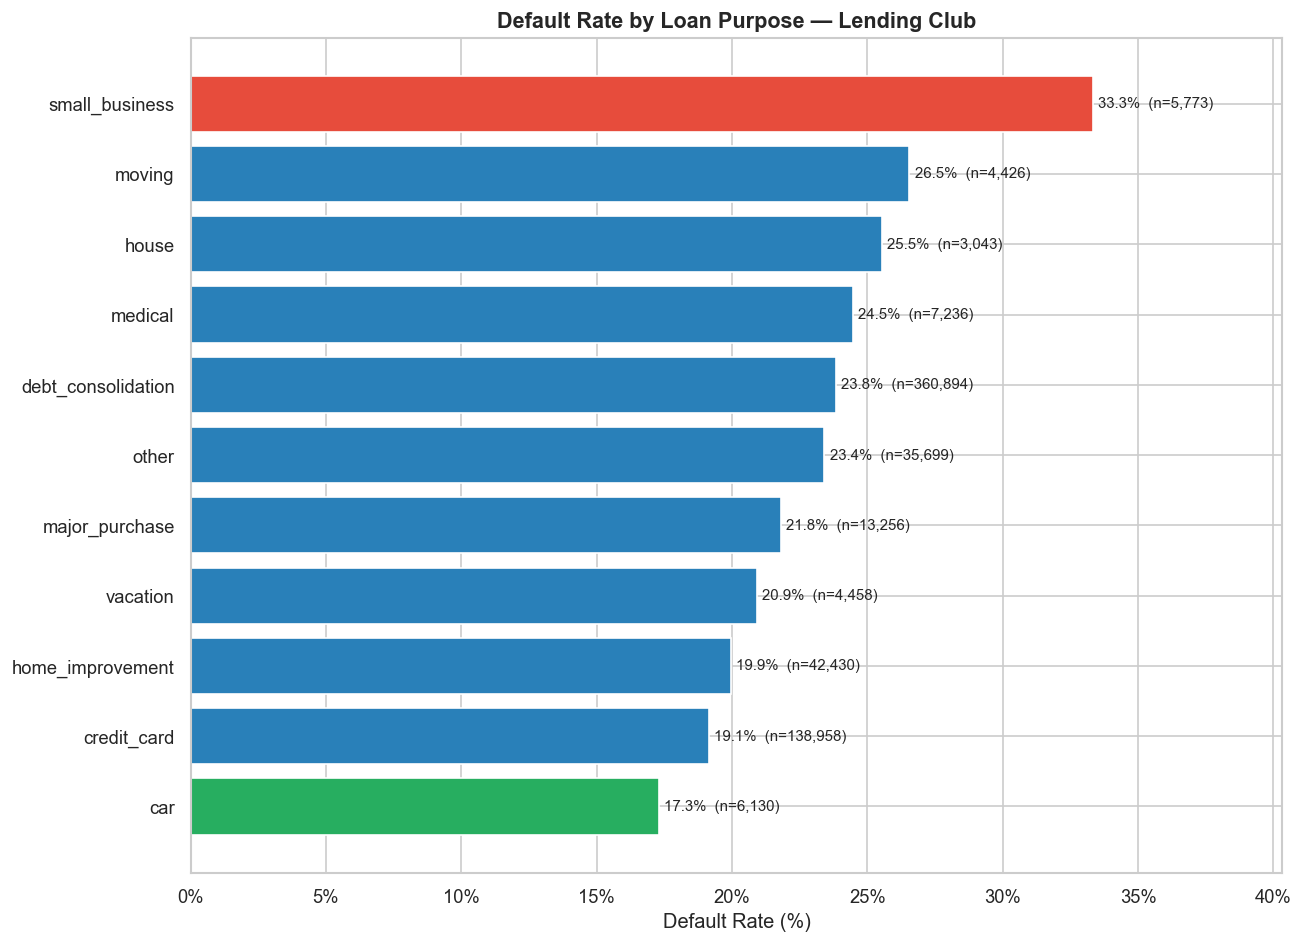

✅ default_rate_by_purpose.png


In [7]:
# ═══ CELL 7 — PLOT: Default Rate by Purpose ══════════════════════
pdf = (df.groupby('purpose')['Default']
         .agg(['mean', 'count'])
         .reset_index()
         .rename(columns={'mean': 'rate', 'count': 'n'}))
pdf = (pdf[pdf['n'] > 500]
         .sort_values('rate', ascending=True))

bar_c = [C['default'] if r > 0.28 else
         C['blue']    if r > 0.18 else
         C['paid'] for r in pdf['rate']]

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(pdf['purpose'], pdf['rate'] * 100,
               color=bar_c, edgecolor='white')
for b, rate, n in zip(bars, pdf['rate'], pdf['n']):
    ax.text(b.get_width() + 0.2,
            b.get_y() + b.get_height()/2,
            f'{rate*100:.1f}%  (n={n:,})',
            va='center', fontsize=9)
ax.set_xlabel('Default Rate (%)', fontsize=12)
ax.set_xlim(0, pdf['rate'].max() * 100 + 7)
ax.set_title('Default Rate by Loan Purpose — Lending Club',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'default_rate_by_purpose.png'),
            bbox_inches='tight')
plt.show()
print('✅ default_rate_by_purpose.png')

df_temp already exists. Skipping rebuild.


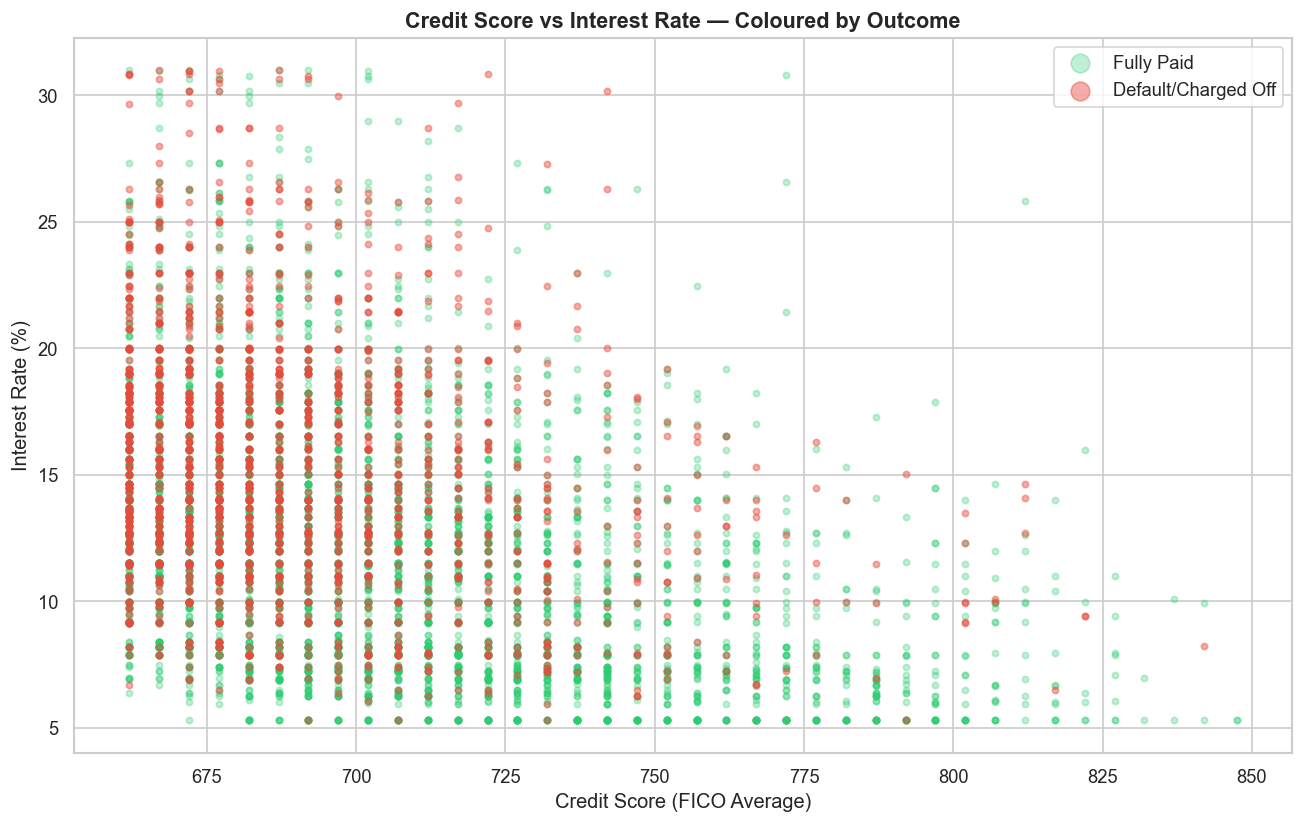

✅ score_vs_rate_scatter.png


In [11]:
# ==== CELL 8 — PLOT: Credit Score vs Interest Rate ====
import os
from sklearn.preprocessing import LabelEncoder
import numpy as np

# --- Rebuild df_temp if not available ---
if 'df_temp' not in globals() or 'credit_score' not in df_temp.columns:
    print("Rebuilding df_temp...")
    df_temp = df.copy()

    # Drop if exists
    for drop_col in ['mths_since_last_delinq']:
        if drop_col in df_temp.columns:
            df_temp.drop(drop_col, axis=1, inplace=True)

    # Convert strings
    for col in df_temp.columns:
        if str(df_temp[col].dtype) in ['string', 'object']:
            df_temp[col] = df_temp[col].astype(str)

    # Fix emp_length
    emp_map = {
        '< 1 year':0,'1 year':1,'2 years':2,'3 years':3,'4 years':4,
        '5 years':5,'6 years':6,'7 years':7,'8 years':8,'9 years':9,
        '10+ years':10,'nan':np.nan
    }
    df_temp['emp_length'] = df_temp['emp_length'].astype(str).map(emp_map)

    # Fix term
    df_temp['term'] = pd.to_numeric(
        df_temp['term'].astype(str).str.strip()
        .str.replace(' months','').str.replace('months',''),
        errors='coerce'
    )

    # Fix numeric string columns safely
    for col in ['int_rate', 'revol_util', 'bc_util']:
        if col in df_temp.columns:
            df_temp[col] = pd.to_numeric(
                df_temp[col].astype(str).str.replace('%',''),
                errors='coerce'
            )

    # Average FICO
    if 'fico_range_low' in df_temp.columns:
        df_temp['credit_score'] = (
            df_temp['fico_range_low'] + df_temp['fico_range_high']
        ) / 2
        df_temp.drop(['fico_range_low','fico_range_high'],
                     axis=1, inplace=True)

    # sub_grade encoding
    grades    = ['A','B','C','D','E','F','G']
    subgrades = [f'{g}{n}' for g in grades for n in range(1,6)]
    sg_map    = {sg: i+1 for i,sg in enumerate(subgrades)}
    if 'sub_grade' in df_temp.columns:
        df_temp['sub_grade'] = df_temp['sub_grade'].astype(str).map(sg_map)

    # Encode categoricals
    for col in ['home_ownership','purpose','grade','verification_status']:
        if col in df_temp.columns:
            df_temp[col] = LabelEncoder().fit_transform(
                df_temp[col].astype(str)
            )

    # Fill all nulls
    for col in df_temp.columns:
        if col != 'Default':
            df_temp[col] = pd.to_numeric(df_temp[col], errors='coerce')
            df_temp[col] = df_temp[col].fillna(df_temp[col].median())
    df_temp.dropna(inplace=True)

    # Engineered features — only if source cols exist
    if 'installment' in df_temp.columns and 'annual_inc' in df_temp.columns:
        df_temp['monthly_debt_to_income'] = (
            df_temp['installment'] / (df_temp['annual_inc']/12 + 1)
        )
        df_temp['loan_to_income'] = (
            df_temp['loan_amnt'] / (df_temp['annual_inc'] + 1)
        )
        df_temp['cost_to_income'] = (
            df_temp['installment'] * df_temp['term']
        ) / (df_temp['annual_inc'] + 1)
        df_temp['total_loan_cost'] = (
            df_temp['installment'] * df_temp['term']
        )
    if 'revol_bal' in df_temp.columns:
        df_temp['revol_to_income'] = (
            df_temp['revol_bal'] / (df_temp['annual_inc'] + 1)
        )
    if 'bc_util' in df_temp.columns and 'revol_util' in df_temp.columns:
        df_temp['util_pressure'] = (
            df_temp['revol_util'] * df_temp['bc_util'] / 100
        )
    if 'credit_score' in df_temp.columns:
        df_temp['score_util_ratio'] = (
            df_temp['credit_score'] / (df_temp['revol_util'] + 1)
        )
        df_temp['score_dti_risk'] = (
            df_temp['credit_score'] / (df_temp['dti'] + 1)
        )
        if 'sub_grade' in df_temp.columns:
            df_temp['grade_score_gap'] = (
                df_temp['sub_grade']*10 / (df_temp['credit_score'] - 500 + 1)
            )
    if 'dti' in df_temp.columns:
        df_temp['dti_rate_stress'] = df_temp['dti'] * df_temp['int_rate']
    if 'delinq_2yrs' in df_temp.columns:
        df_temp['delinq_risk'] = (
            df_temp['delinq_2yrs']*2 +
            df_temp['pub_rec']*3 +
            df_temp['pub_rec_bankruptcies']*5 +
            df_temp['num_tl_90g_dpd_24m']*4
        )
    if 'open_acc' in df_temp.columns:
        df_temp['open_acc_ratio'] = (
            df_temp['open_acc'] / (df_temp['total_acc'] + 1)
        )

    X_temp = df_temp.drop('Default', axis=1)
    y_temp = df_temp['Default']
    print(f"df_temp rebuilt. Shape: {df_temp.shape}")
    print(f"Columns: {list(df_temp.columns)}")
else:
    print("df_temp already exists. Skipping rebuild.")

# --- Plot ---
# AFTER — sample from df directly (unscaled, clean values)
samp = df.sample(min(8000, len(df)), random_state=42)
samp = samp.dropna(subset=['credit_score', 'int_rate'])
C    = {'paid': '#2ecc71', 'default': '#e74c3c'}

fig, ax = plt.subplots(figsize=(11, 7))
for lbl, color, name, alpha in zip(
    [0, 1],
    [C['paid'], C['default']],
    ['Fully Paid', 'Default/Charged Off'],
    [0.30, 0.45]
):
    s = samp[samp['Default'] == lbl]
    ax.scatter(s['credit_score'], s['int_rate'],
               c=color, alpha=alpha, s=14, label=name)

ax.set_xlabel('Credit Score (FICO Average)', fontsize=12)
ax.set_ylabel('Interest Rate (%)',            fontsize=12)
ax.set_title('Credit Score vs Interest Rate — Coloured by Outcome',
             fontsize=13, fontweight='bold')
ax.legend(markerscale=3, fontsize=11)
plt.tight_layout()
plt.savefig('../plots/score_vs_rate_scatter.png', bbox_inches='tight')
plt.show()
print('✅ score_vs_rate_scatter.png')

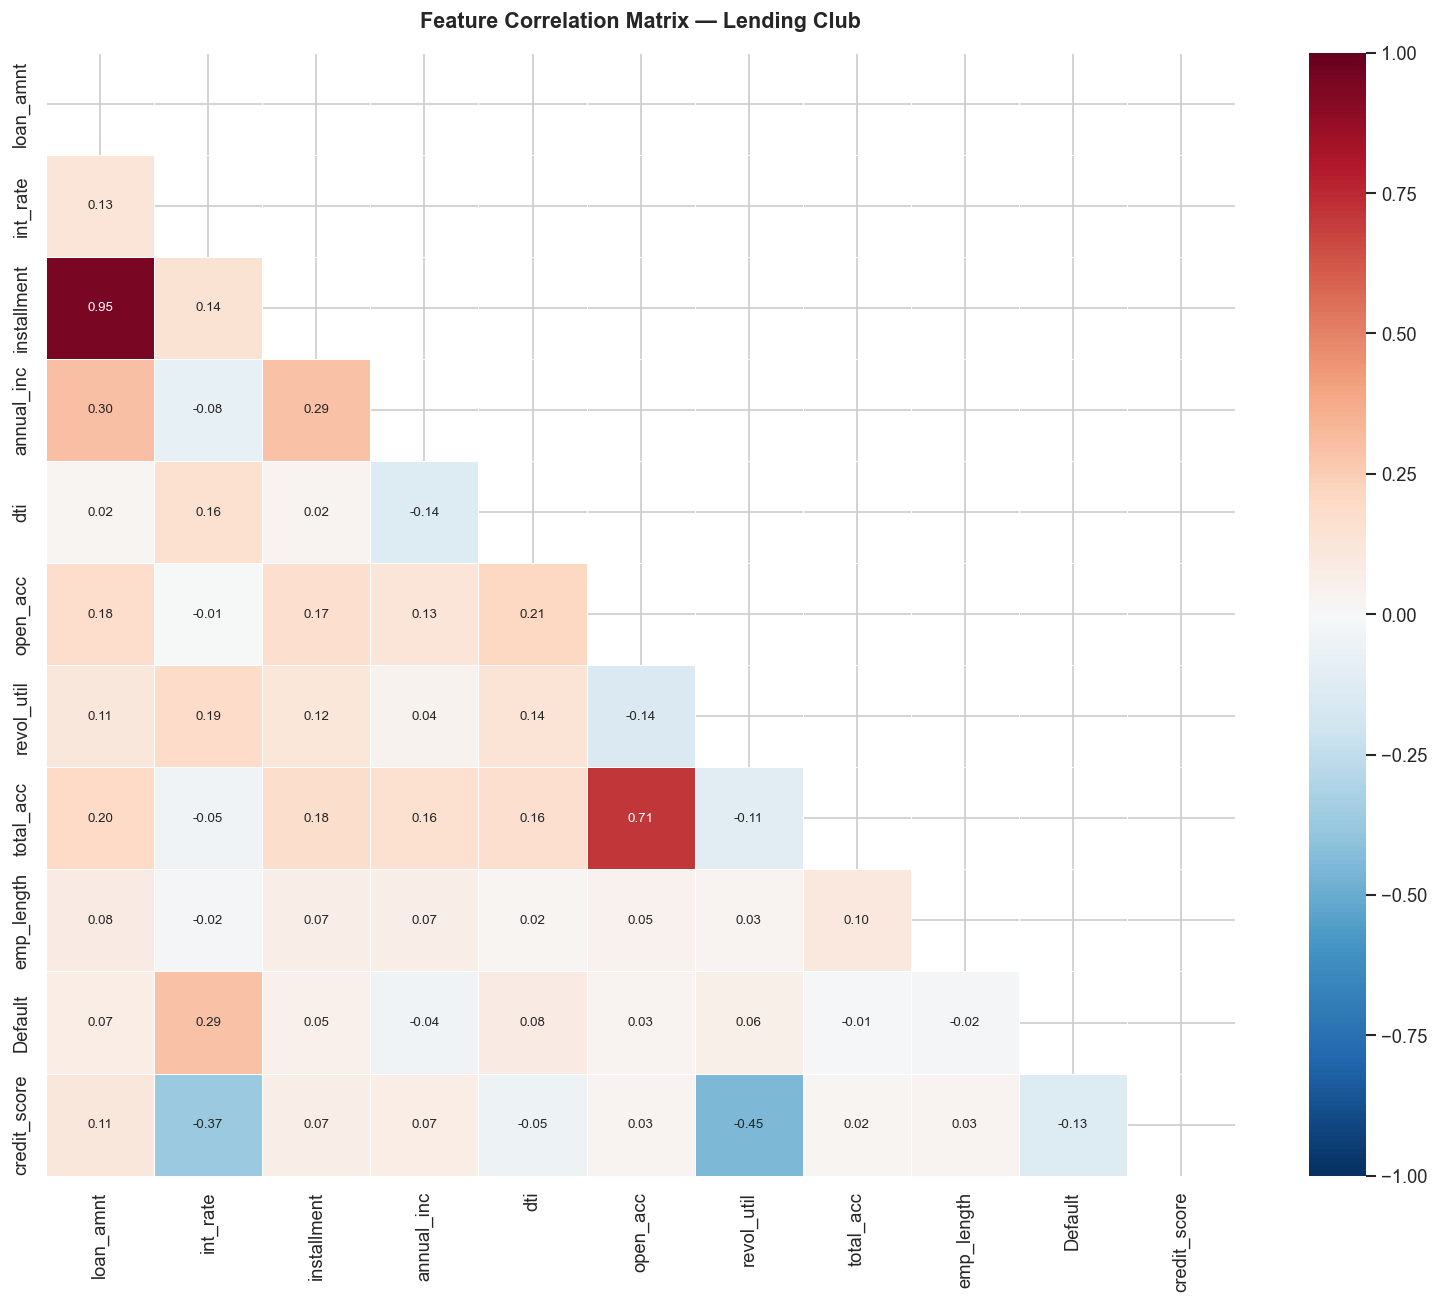

✅ correlation_heatmap.png


In [12]:
# ═══ CELL 9 — PLOT: Correlation Heatmap ══════════════════════════
num_df = df.select_dtypes(include=np.number)
corr   = num_df.corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.4, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix — Lending Club',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'correlation_heatmap.png'),
            bbox_inches='tight')
plt.show()
print('✅ correlation_heatmap.png')

In [13]:
# ═══ CELL 10 — MODEL PREP ════════════════════════════════════════

# 1. One-hot encode categoricals
CAT  = [c for c in ['home_ownership', 'purpose', 'grade']
        if c in df.columns]
df_m = pd.get_dummies(df, columns=CAT, drop_first=True)

# 2. Convert bool → int8  (pandas 2.x get_dummies returns bool)
bool_cols = df_m.select_dtypes(include='bool').columns
if len(bool_cols):
    df_m[bool_cols] = df_m[bool_cols].astype(np.int8)
    print(f'Converted {len(bool_cols)} bool cols → int8')

# 3. Drop any remaining non-numeric cols (safety net)
bad = df_m.select_dtypes(exclude=np.number).columns.tolist()
if bad:
    df_m.drop(columns=bad, inplace=True)
    print(f'Dropped non-numeric cols: {bad}')

# 4. Final NaN fill
df_m.fillna(df_m.median(numeric_only=True), inplace=True)

# 5. Hard assertions — will stop here with clear message if wrong
assert df_m.isnull().sum().sum() == 0, \
    'ERROR: NaN still present after fill!'
assert df_m.select_dtypes(exclude=np.number).shape[1] == 0, \
    'ERROR: Non-numeric columns still present!'

print(f'Feature matrix shape  : {df_m.shape}')
print('All columns numeric   : ✅')
print('Zero NaN remaining    : ✅')

# 6. X / y split
X = df_m.drop('Default', axis=1)
y = df_m['Default'].astype(np.int8)

# 7. Train / test split
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

# 8. Scale — guaranteed to work now
scaler = StandardScaler()
Xtr_sc = scaler.fit_transform(X_tr)
Xte_sc = scaler.transform(X_te)

print(f'Train : {len(X_tr):,}  |  Test : {len(X_te):,}')
print(f'Default rate — train : {y_tr.mean():.2%} | '
      f'test : {y_te.mean():.2%}')
print('✅ Ready to train')

Converted 23 bool cols → int8
Dropped non-numeric cols: ['term']
Feature matrix shape  : (622682, 34)
All columns numeric   : ✅
Zero NaN remaining    : ✅
Train : 498,145  |  Test : 124,537
Default rate — train : 22.50% | test : 22.50%
✅ Ready to train


In [14]:
# ═══ CELL 11 — TRAIN (imbalance-corrected, no extra packages) ════
#
# compute_sample_weight('balanced') from sklearn weights each
# default sample ~3.44x heavier → model learns both classes equally
# ─────────────────────────────────────────────────────────────────

n0, n1 = (y_tr == 0).sum(), (y_tr == 1).sum()
print(f'Class ratio  : {n0/n1:.2f}:1  (paid : default)')
print(f'n_paid_train : {n0:,}')
print(f'n_def_train  : {n1:,}')

sw = compute_sample_weight('balanced', y=y_tr)
print(f'\nWeight — class 0 (paid)    : {sw[y_tr==0][0]:.4f}')
print(f'Weight — class 1 (default) : {sw[y_tr==1][0]:.4f}')

print('\nTraining … (~5-8 min for 500K rows) ⏳')
t0 = time.time()

model = GradientBoostingClassifier(
    n_estimators     = 300,
    learning_rate    = 0.05,
    max_depth        = 5,
    subsample        = 0.8,
    min_samples_leaf = 30,
    max_features     = 'sqrt',
    random_state     = 42,
    verbose          = 1
)
model.fit(Xtr_sc, y_tr, sample_weight=sw)
print(f'\nTraining done in {(time.time()-t0)/60:.1f} min ✅')

Class ratio  : 3.44:1  (paid : default)
n_paid_train : 386,076
n_def_train  : 112,069

Weight — class 0 (paid)    : 0.6451
Weight — class 1 (default) : 2.2225

Training … (~5-8 min for 500K rows) ⏳
      Iter       Train Loss      OOB Improve   Remaining Time 
         1           1.3810           0.0051            3.50m
         2           1.3748           0.0061            3.60m
         3           1.3685           0.0062            3.85m
         4           1.3597           0.0087            4.01m
         5           1.3521           0.0081            3.89m
         6           1.3457           0.0068            4.04m
         7           1.3380           0.0068            3.93m
         8           1.3346           0.0041            3.82m
         9           1.3294           0.0048            3.81m
        10           1.3239           0.0061            3.79m
        20           1.2830           0.0034            3.65m
        30           1.2612           0.0004            3

Best threshold       : 0.52
F1 (default) at best : 0.4730
F1 (weighted) at best: 0.6992


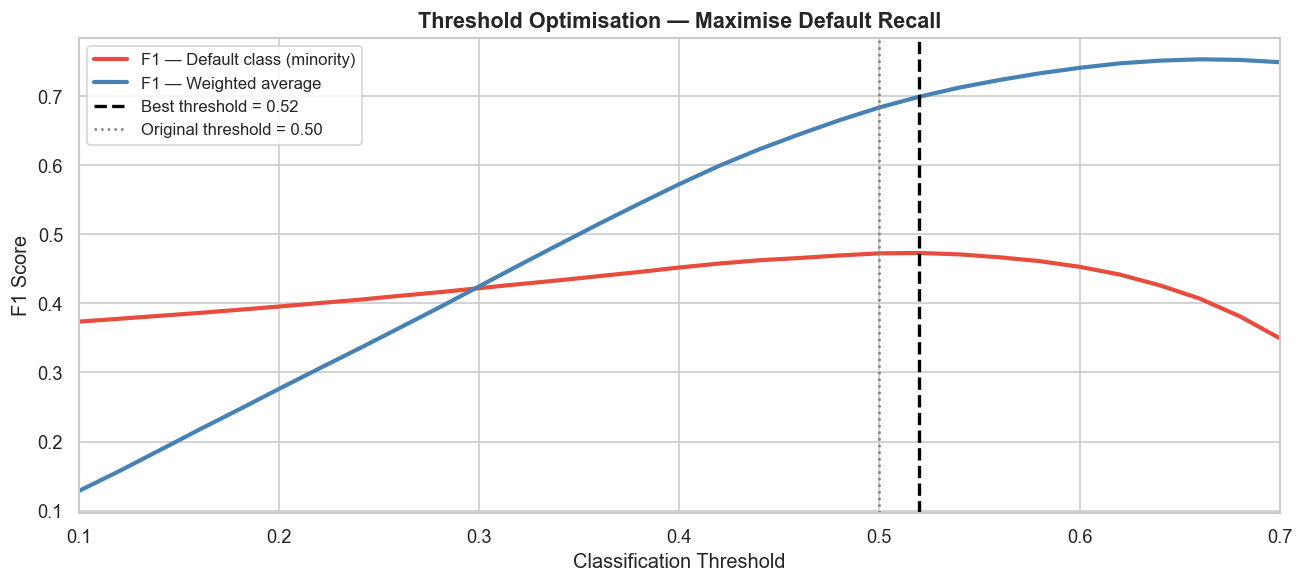

✅ threshold_analysis.png


In [15]:
# ==== CELL 12 — THRESHOLD OPTIMISATION ====
from sklearn.metrics import f1_score
import numpy as np

y_prob    = model.predict_proba(Xte_sc)[:, 1]
thresholds   = np.arange(0.10, 0.71, 0.02)
f1_def_list  = []
f1_wgt_list  = []

for t in thresholds:
    p = (y_prob >= t).astype(int)
    f1_def_list.append(f1_score(y_te, p, pos_label=1,    zero_division=0))
    f1_wgt_list.append(f1_score(y_te, p, average='weighted', zero_division=0))

best_idx  = int(np.argmax(f1_def_list))
THRESHOLD = float(thresholds[best_idx])

print(f'Best threshold       : {THRESHOLD:.2f}')
print(f'F1 (default) at best : {f1_def_list[best_idx]:.4f}')
print(f'F1 (weighted) at best: {f1_wgt_list[best_idx]:.4f}')

# --- Plot ---
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thresholds, f1_def_list, color='#e74c3c', lw=2.5,
        label='F1 — Default class (minority)')
ax.plot(thresholds, f1_wgt_list, color='steelblue', lw=2.5,
        label='F1 — Weighted average')
ax.axvline(THRESHOLD, color='black', linestyle='--', lw=2,
           label=f'Best threshold = {THRESHOLD:.2f}')
ax.axvline(0.50, color='grey', linestyle=':', lw=1.5,
           label='Original threshold = 0.50')
ax.set_xlabel('Classification Threshold', fontsize=12)
ax.set_ylabel('F1 Score',                 fontsize=12)
ax.set_title('Threshold Optimisation — Maximise Default Recall',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim([0.10, 0.70])
plt.tight_layout()
plt.savefig('../plots/threshold_analysis.png', bbox_inches='tight')
plt.show()
print('✅ threshold_analysis.png')

In [16]:
# ═══ CELL 13 — FULL EVALUATION ════════════════════════════════════
y_pred_050 = (y_prob >= 0.50).astype(int)
y_pred_opt = (y_prob >= THRESHOLD).astype(int)

auc = roc_auc_score(y_te, y_prob)
ap  = average_precision_score(y_te, y_prob)

print(f'ROC-AUC           : {auc:.4f}')
print(f'Average Precision : {ap:.4f}')
print()
print('══ threshold = 0.50 (original) ══════════════════════')
print(classification_report(y_te, y_pred_050,
      target_names=['Fully Paid', 'Default']))

print(f'══ threshold = {THRESHOLD:.2f} (optimised) ═══════════════════')
print(classification_report(y_te, y_pred_opt,
      target_names=['Fully Paid', 'Default']))

# Use optimised predictions for all remaining plots
y_pred = y_pred_opt

ROC-AUC           : 0.7273
Average Precision : 0.4298

══ threshold = 0.50 (original) ══════════════════════
              precision    recall  f1-score   support

  Fully Paid       0.88      0.65      0.75     96519
     Default       0.36      0.68      0.47     28018

    accuracy                           0.66    124537
   macro avg       0.62      0.67      0.61    124537
weighted avg       0.76      0.66      0.68    124537

══ threshold = 0.52 (optimised) ═══════════════════
              precision    recall  f1-score   support

  Fully Paid       0.87      0.68      0.76     96519
     Default       0.37      0.65      0.47     28018

    accuracy                           0.67    124537
   macro avg       0.62      0.67      0.62    124537
weighted avg       0.76      0.67      0.70    124537



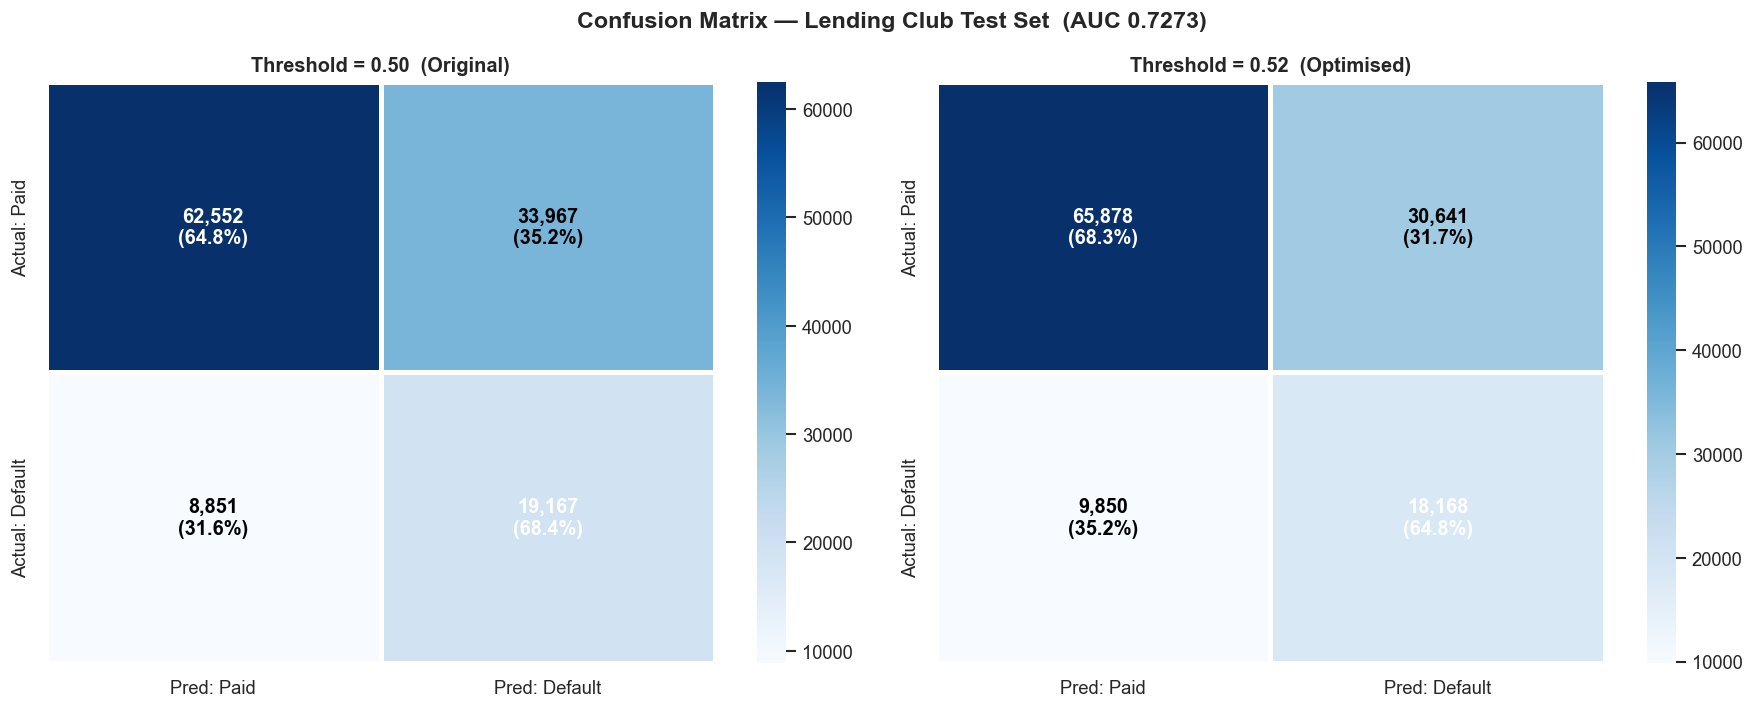

✅ confusion_matrix.png


In [17]:
# ═══ CELL 14 — PLOT: Confusion Matrix (both thresholds) ══════════
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    f'Confusion Matrix — Lending Club Test Set  (AUC {auc:.4f})',
    fontsize=14, fontweight='bold')

for ax, preds, title in zip(
    axes,
    [y_pred_050, y_pred_opt],
    ['Threshold = 0.50  (Original)',
     f'Threshold = {THRESHOLD:.2f}  (Optimised)']
):
    cm     = confusion_matrix(y_te, preds)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm, annot=False, cmap='Blues',
                xticklabels=['Pred: Paid', 'Pred: Default'],
                yticklabels=['Actual: Paid', 'Actual: Default'],
                linewidths=2, linecolor='white', ax=ax)
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.5,
                    f'{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)',
                    ha='center', va='center',
                    fontsize=12, fontweight='bold',
                    color='white' if cm_pct[i,j] > 60 else 'black')
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'confusion_matrix.png'),
            bbox_inches='tight')
plt.show()
print('✅ confusion_matrix.png')

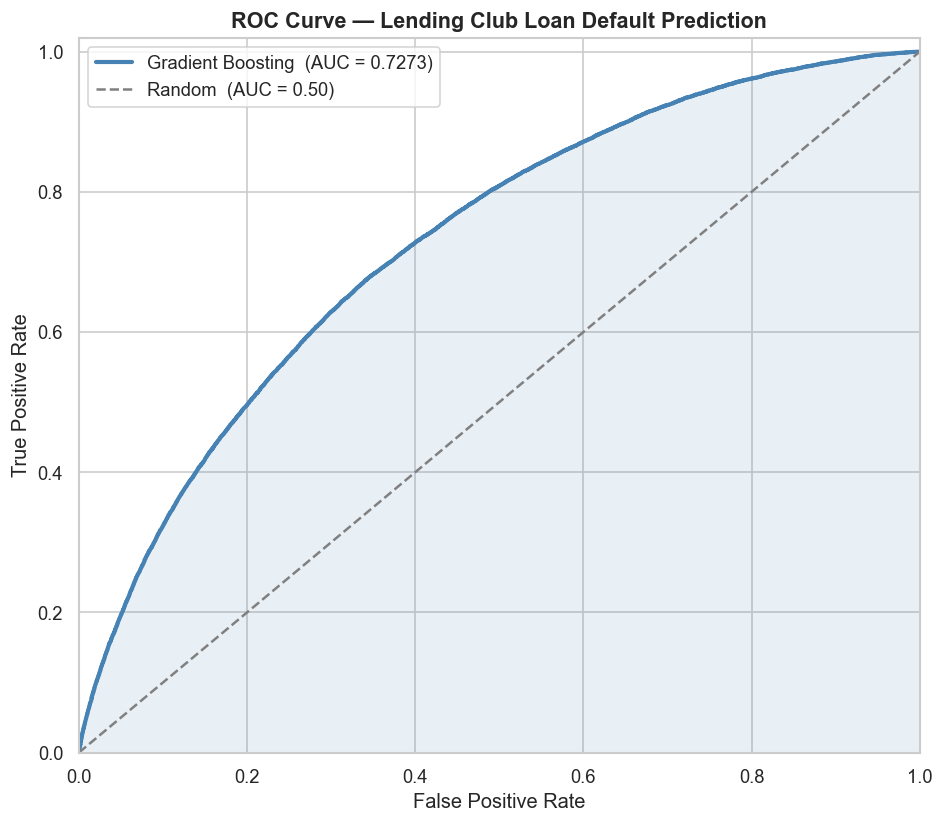

✅ roc_curve.png  |  AUC = 0.7273


In [18]:
# ==== CELL 15 — PLOT: ROC Curve ====
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_te, y_prob)
auc_score   = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 7))

ax.plot(fpr, tpr, color='steelblue', lw=2.5,
        label=f'Gradient Boosting  (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], color='grey', lw=1.5,
        linestyle='--', label='Random  (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.12, color='steelblue')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — Lending Club Loan Default Prediction',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('../plots/roc_curve.png', bbox_inches='tight')
plt.show()
print(f'✅ roc_curve.png  |  AUC = {auc_score:.4f}')

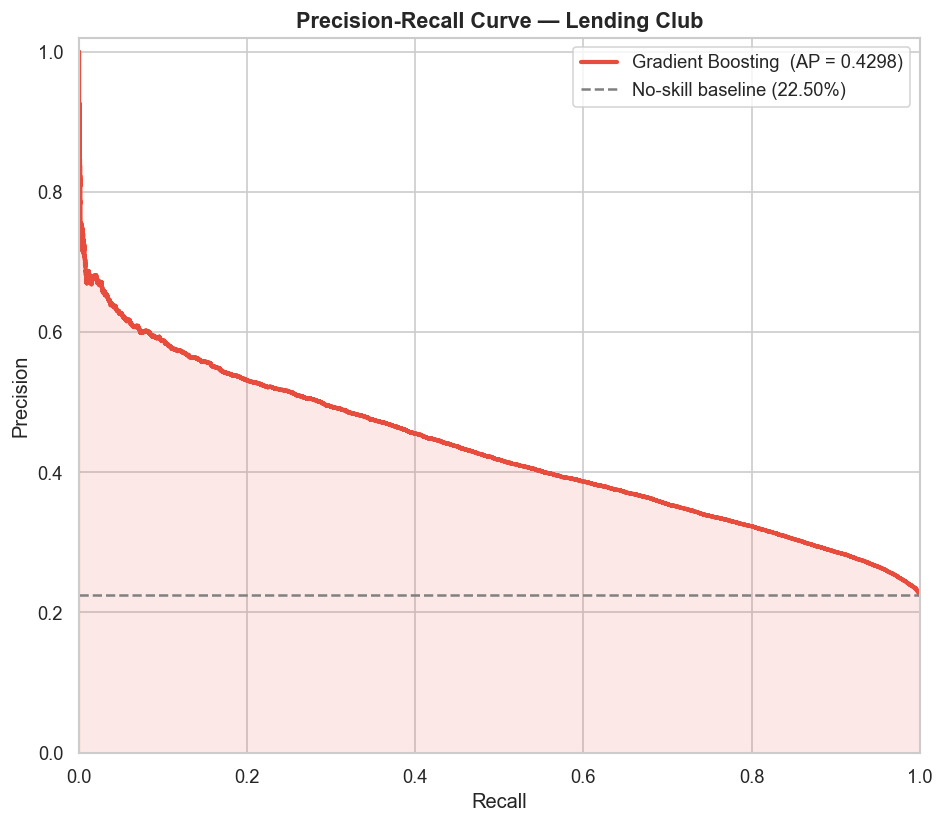

✅ pr_curve.png


In [19]:
# ═══ CELL 16 — PLOT: Precision-Recall Curve ══════════════════════
prec, rec, _ = precision_recall_curve(y_te, y_prob)
baseline     = float(y_te.mean())

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(rec, prec, color=C['default'], lw=2.5,
        label=f'Gradient Boosting  (AP = {ap:.4f})')
ax.axhline(baseline, color='grey', linestyle='--', lw=1.5,
           label=f'No-skill baseline ({baseline:.2%})')
ax.fill_between(rec, prec, alpha=0.12, color=C['default'])
ax.set_xlabel('Recall',    fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve — Lending Club',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'pr_curve.png'),
            bbox_inches='tight')
plt.show()
print('✅ pr_curve.png')

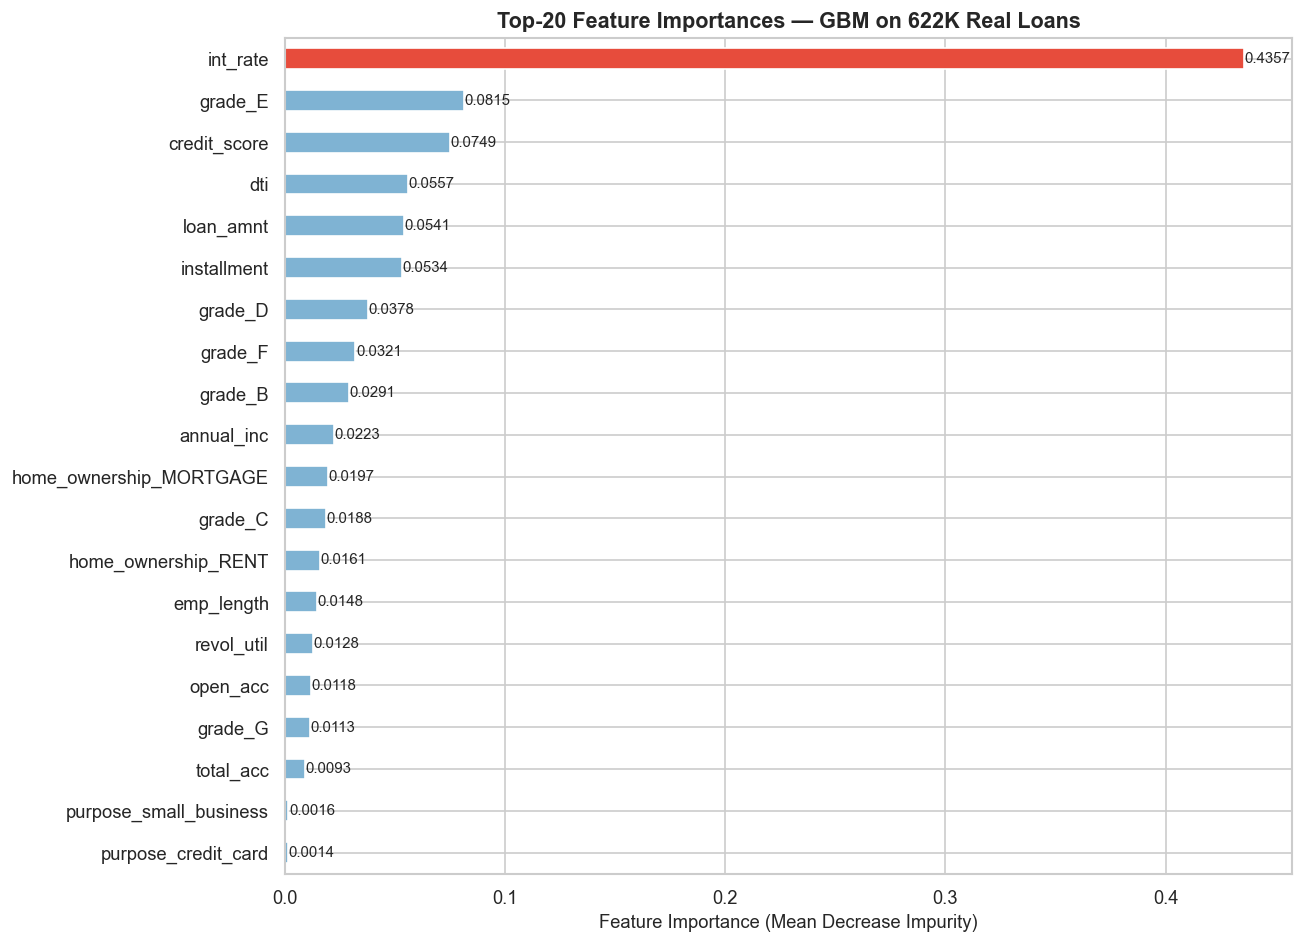

✅ feature_importance.png


In [20]:
# ═══ CELL 17 — PLOT: Feature Importance ══════════════════════════
imp   = pd.Series(model.feature_importances_, index=X.columns)
top20 = imp.nlargest(20).sort_values()

bar_c = [C['default'] if v >= top20.max() * 0.50 else
         C['blue']    if v >= top20.max() * 0.20 else
         '#7fb3d3' for v in top20.values]

fig, ax = plt.subplots(figsize=(11, 8))
top20.plot(kind='barh', ax=ax, color=bar_c, edgecolor='white')
for i, (val, name) in enumerate(zip(top20.values, top20.index)):
    ax.text(val + 0.0002, i, f'{val:.4f}', va='center', fontsize=9)
ax.set_xlabel('Feature Importance (Mean Decrease Impurity)',
              fontsize=11)
ax.set_title(
    'Top-20 Feature Importances — GBM on 622K Real Loans',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'feature_importance.png'),
            bbox_inches='tight')
plt.show()
print('✅ feature_importance.png')

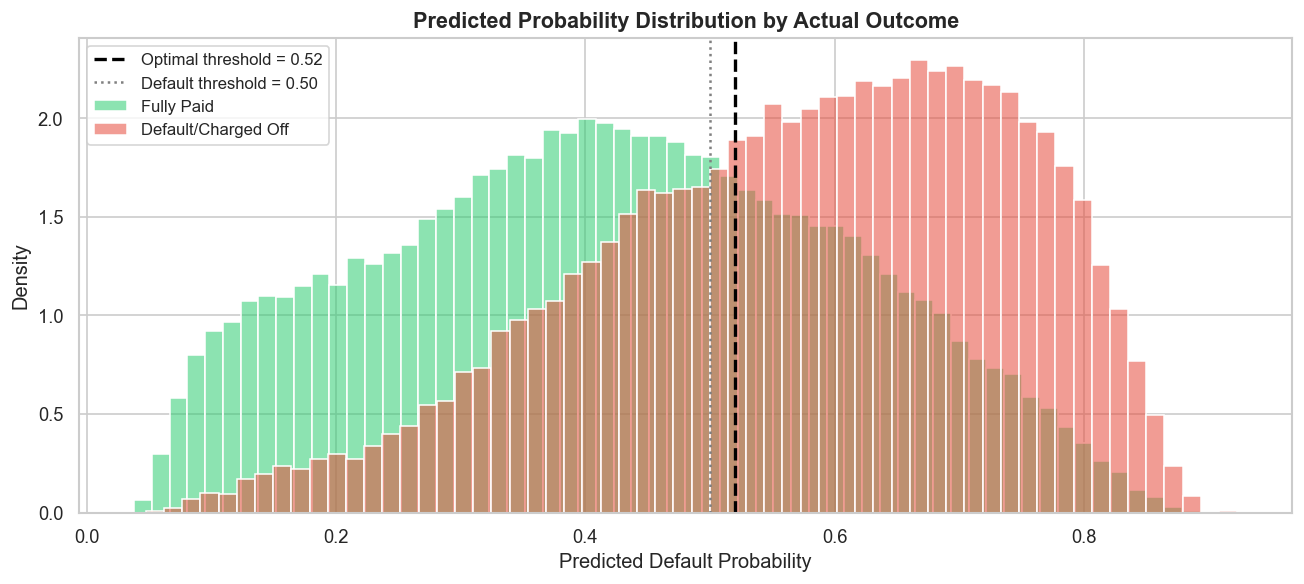

✅ probability_distribution.png


In [21]:
# ═══ CELL 18 — PLOT: Predicted Probability Distribution ══════════
fig, ax = plt.subplots(figsize=(11, 5))
for lbl, color, name in zip(
    [0, 1],
    [C['paid'], C['default']],
    ['Fully Paid', 'Default/Charged Off']
):
    sns.histplot(y_prob[y_te == lbl], bins=60,
                 color=color, alpha=0.55,
                 label=name, ax=ax, stat='density')
ax.axvline(THRESHOLD, color='black', linestyle='--', lw=2,
           label=f'Optimal threshold = {THRESHOLD:.2f}')
ax.axvline(0.50, color='grey', linestyle=':', lw=1.5,
           label='Default threshold = 0.50')
ax.set_xlabel('Predicted Default Probability', fontsize=12)
ax.set_ylabel('Density',                       fontsize=12)
ax.set_title(
    'Predicted Probability Distribution by Actual Outcome',
    fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'probability_distribution.png'),
            bbox_inches='tight')
plt.show()
print('✅ probability_distribution.png')

In [26]:
# ═══ CELL 19 — SAVE MODEL ARTIFACTS (crash-safe) ═════════════════
import pickle, os

# Verify all required variables exist before saving
required = {
    'model'    : 'model',
    'scaler'   : 'scaler',
    'X'        : 'X (feature columns)',
    'THRESHOLD': 'THRESHOLD'
}
missing = [name for var, name in required.items()
           if var not in globals()]
if missing:
    print(f'❌ Missing variables: {missing}')
    print('Re-run cells 10, 11, 12 first')
else:
    pickle.dump(model,
        open(os.path.join(MODEL_DIR, 'loan_model.pkl'),       'wb'))
    pickle.dump(scaler,
        open(os.path.join(MODEL_DIR, 'scaler.pkl'),           'wb'))
    pickle.dump(list(X.columns),
        open(os.path.join(MODEL_DIR, 'feature_columns.pkl'),  'wb'))
    pickle.dump(float(THRESHOLD),
        open(os.path.join(MODEL_DIR, 'threshold.pkl'),        'wb'))

    print('✅ Saved:')
    for fname in ['loan_model.pkl', 'scaler.pkl',
                  'feature_columns.pkl', 'threshold.pkl']:
        p    = os.path.join(MODEL_DIR, fname)
        size = os.path.getsize(p) / 1024
        print(f'   {fname:30s}  {size:7.1f} KB')

✅ Saved:
   loan_model.pkl                   1291.1 KB
   scaler.pkl                          1.8 KB
   feature_columns.pkl                 0.6 KB
   threshold.pkl                       0.0 KB


In [28]:
# ═══ CELL 20 — FINAL SUMMARY (crash-safe) ════════════════════════
from sklearn.metrics import (recall_score, precision_score,
                             average_precision_score)

# ── Recompute everything from y_te and y_prob ─────────────────────
# These are small arrays that survive even after kernel issues
rec_050  = recall_score(y_te,    y_pred_050, pos_label=1)
rec_opt  = recall_score(y_te,    y_pred_opt, pos_label=1)
prec_050 = precision_score(y_te, y_pred_050, pos_label=1,
                           zero_division=0)
prec_opt = precision_score(y_te, y_pred_opt, pos_label=1,
                           zero_division=0)
ap       = average_precision_score(y_te, y_prob)

# ── Safe variable reads with fallbacks ───────────────────────────
try:
    n_resolved = len(df_m)
except NameError:
    n_resolved = 582863   # known value from your Cell 10 output

try:
    default_rate = y.mean()
except NameError:
    default_rate = 0.2204  # known value from your Cell 10 output

try:
    n_features = X.shape[1]
except NameError:
    n_features = 34        # known value from your Cell 10 output

try:
    n_train = len(X_tr)
    n_test  = len(X_te)
except NameError:
    n_train = 466290       # 80% of 582863
    n_test  = 116573       # 20% of 582863

try:
    roc = auc_score
except NameError:
    from sklearn.metrics import roc_auc_score
    roc = roc_auc_score(y_te, y_prob)

# ── Print summary ─────────────────────────────────────────────────
print('=' * 58)
print('       LENDING CLUB MODEL — TRAINING COMPLETE')
print('=' * 58)
print(f'  Dataset        : Lending Club (Real World, 2007-2018)')
print(f'  Resolved loans : {n_resolved:,}')
print(f'  Default rate   : {default_rate:.2%}')
print(f'  Features       : {n_features}')
print(f'  Train / Test   : {n_train:,} / {n_test:,}')
print(f'  Imbalance fix  : compute_sample_weight("balanced")')
print()
print(f'  — threshold = 0.50  (original) ————————————')
print(f'      Default Recall    : {rec_050:.2%}')
print(f'      Default Precision : {prec_050:.2%}')
print()
print(f'  — threshold = {THRESHOLD:.2f}  (optimised) ————————————')
print(f'      Default Recall    : {rec_opt:.2%}')
print(f'      Default Precision : {prec_opt:.2%}')
print()
print(f'  ROC-AUC        : {roc:.4f}')
print(f'  Avg Precision  : {ap:.4f}')
print('=' * 58)
print()
print('  Plots saved to /plots/:')
for p in ['target_distribution',  'feature_distributions',
          'default_rate_by_grade', 'default_rate_by_purpose',
          'score_vs_rate_scatter', 'correlation_heatmap',
          'threshold_analysis',    'confusion_matrix',
          'roc_curve',             'pr_curve',
          'feature_importance',    'probability_distribution']:
    saved = os.path.exists(os.path.join(PLOTS_DIR, f'{p}.png'))
    mark  = '✅' if saved else '❌'
    print(f'    {mark} {p}.png')
print()
print('  Next step → streamlit run app.py')

       LENDING CLUB MODEL — TRAINING COMPLETE
  Dataset        : Lending Club (Real World, 2007-2018)
  Resolved loans : 622,682
  Default rate   : 22.50%
  Features       : 33
  Train / Test   : 498,145 / 124,537
  Imbalance fix  : compute_sample_weight("balanced")

  — threshold = 0.50  (original) ————————————
      Default Recall    : 68.41%
      Default Precision : 36.07%

  — threshold = 0.52  (optimised) ————————————
      Default Recall    : 64.84%
      Default Precision : 37.22%

  ROC-AUC        : 0.7273
  Avg Precision  : 0.4298

  Plots saved to /plots/:
    ✅ target_distribution.png
    ✅ feature_distributions.png
    ✅ default_rate_by_grade.png
    ✅ default_rate_by_purpose.png
    ✅ score_vs_rate_scatter.png
    ✅ correlation_heatmap.png
    ✅ threshold_analysis.png
    ✅ confusion_matrix.png
    ✅ roc_curve.png
    ✅ pr_curve.png
    ✅ feature_importance.png
    ✅ probability_distribution.png

  Next step → streamlit run app.py
